In [7]:
"""
    This is a demo notebook to test the quick_eda package and show how to use it.
    Along with example usage, it also reloads all the modules to reflect recent changes without needing to restart the kernel.
"""

import importlib
import quick_eda.classifier
import quick_eda.profiler
import quick_eda.relationships
import quick_eda.suggestions
import quick_eda.renderer
import quick_eda.plots
import quick_eda.core
import quick_eda

importlib.reload(quick_eda.classifier)
importlib.reload(quick_eda.profiler)
importlib.reload(quick_eda.relationships)
importlib.reload(quick_eda.suggestions)
importlib.reload(quick_eda.renderer)
importlib.reload(quick_eda.plots)
importlib.reload(quick_eda.core)
importlib.reload(quick_eda)

print("✓ quick_eda reloaded")

✓ quick_eda reloaded



  quick_eda
────────────────────────────────────────────────────
  rows               900
  columns              5
  missing           0.0%
  duplicates         862  !
  memory           0.15 MB
  numeric              1
  categorical          3
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  MODERATE
    user_country                    Imbalanced — 'US' dominates 94% of rows, may cause model bias
    rare_feature                    Imbalanced — 'A' dominates 98% of rows, may cause model bias
    numeric_price                   Apply log transform — right-skewed distribution (skew +1.14)

─── SUGGESTIONS ───

   1.  Remove 862 duplicate rows
   2.  [user_country]  Imbalanced — 'US' dominates 94% of rows, may cause model bias
   3.  [rare_feature]  Imbalanced — 'A' dominates 98% of rows, may cause model bias
   4.  [numeric_price]  Apply log transform — right-skewed distribution (skew +1.14)
   5.  [numeric_price]  Investigate outliers 

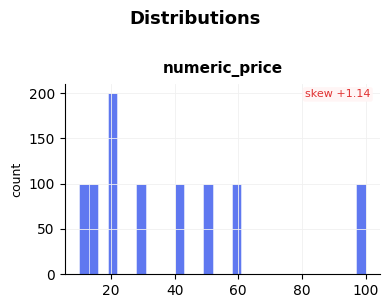

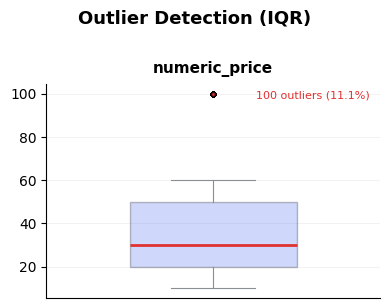

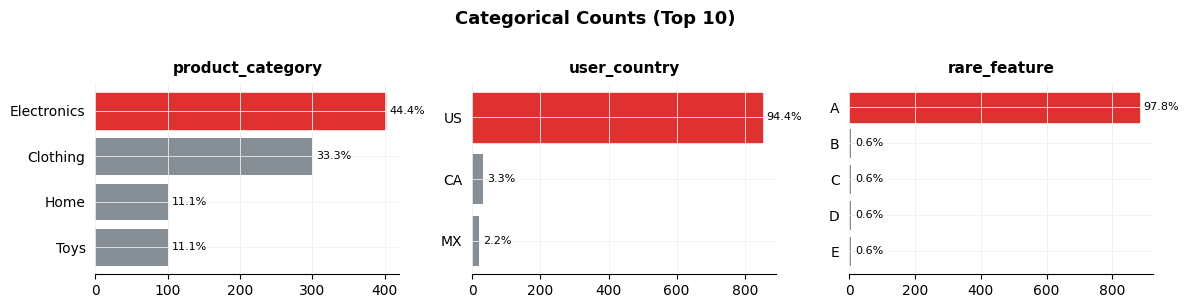

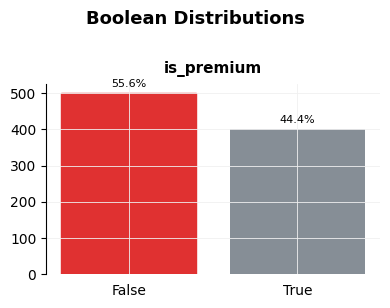

In [8]:
# ----------------------------------------------------
# Showcasing v0.2.0: Categorical Intelligence
# Using a dataset with distinct categorical and boolean features.
# ----------------------------------------------------
import pandas as pd
import quick_eda as qeda

df_cat = pd.DataFrame({
    "product_category": ["Electronics", "Clothing", "Electronics", "Home", "Clothing", "Electronics", "Toys", "Electronics", "Clothing"] * 100,
    "is_premium": [True, False, True, False, False, True, False, True, False] * 100,
    "user_country": ["US"] * 850 + ["CA"] * 30 + ["MX"] * 20, # Very imbalanced category
    "rare_feature": ["A"] * 880 + ["B", "C", "D", "E"] * 5, # Lots of rare cats
    "numeric_price": [19.99, 29.99, 49.99, 99.99, 15.00, 20.00, 9.99, 59.99, 39.99] * 100
})

# Note the new `cat_threshold` argument to override when a column is categorical!
qeda.quick_eda(df_cat, cat_threshold=20)



  quick_eda
────────────────────────────────────────────────────
  rows             1,000
  columns              2
  missing           0.0%
  duplicates           0
  memory           0.02 MB
  numeric              2
  categorical          0
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  MODERATE
    income                          Apply log transform — right-skewed distribution (skew +1.90)
    profit_margin                   Consider power transform (Box-Cox) — column has negative values, log transform not applicable

─── SUGGESTIONS ───

   1.  [income]  Apply log transform — right-skewed distribution (skew +1.90)
   2.  [income]  Heavy-tailed distribution (kurtosis 5.15) — extreme values may affect model
   3.  [profit_margin]  Consider power transform (Box-Cox) — column has negative values, log transform not applicable
   4.  [profit_margin]  Some outliers present — 5.9% beyond IQR bounds, review before modeling
   5.  [profit_m

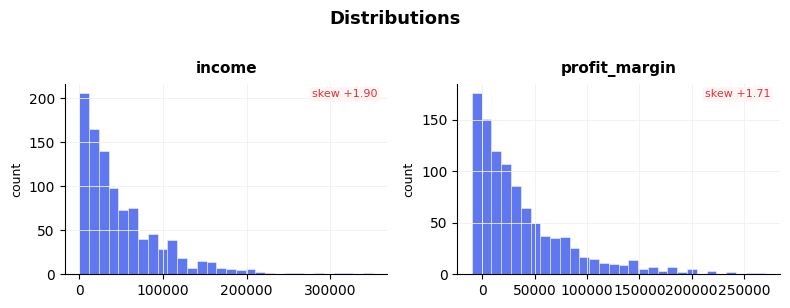

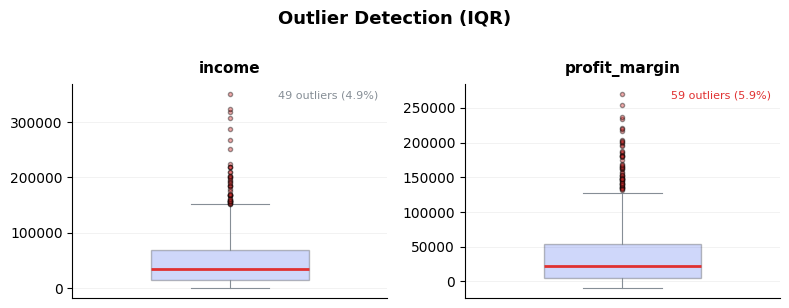

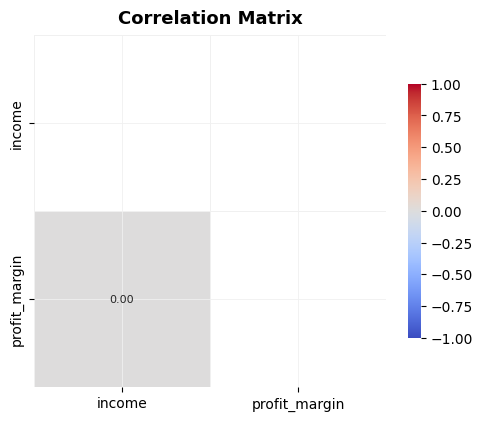

In [9]:
# ----------------------------------------------------
# Showcasing v0.1.1: Box-Cox on skewed negative values
# In earlier versions, this generated an invalid 'log transform' suggestion.
# ----------------------------------------------------
import numpy as np

# Generate negatively skewed data with bounds below 0
df_skew = pd.DataFrame({
    # normal right skew (gets log transform safely)
    "income": np.random.exponential(50000, 1000),
    # negative minimum right skew (gets power transform suggestion)
    "profit_margin": np.random.exponential(50000, 1000) - 10000
})

qeda.quick_eda(df_skew)



  quick_eda
────────────────────────────────────────────────────
  rows             3,204
  columns             14
  missing           0.0%
  duplicates           0
  memory           0.97 MB
  numeric             10
  categorical          4
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  HIGH CONCERN
    units_sold                      High correlation with 'demand_forecast' (0.88) — consider dropping one before modeling
    demand_forecast                 High correlation with 'units_sold' (0.88) — consider dropping one before modeling

─── SUGGESTIONS ───

   1.  [units_sold]  High correlation with 'demand_forecast' (0.88) — consider dropping one before modeling
   2.  [demand_forecast]  High correlation with 'units_sold' (0.88) — consider dropping one before modeling

─── COLUMN STATS ───


  NUMERIC STATS

                          count  missing %      mean   median       std    min     max    skew  outliers %
column            

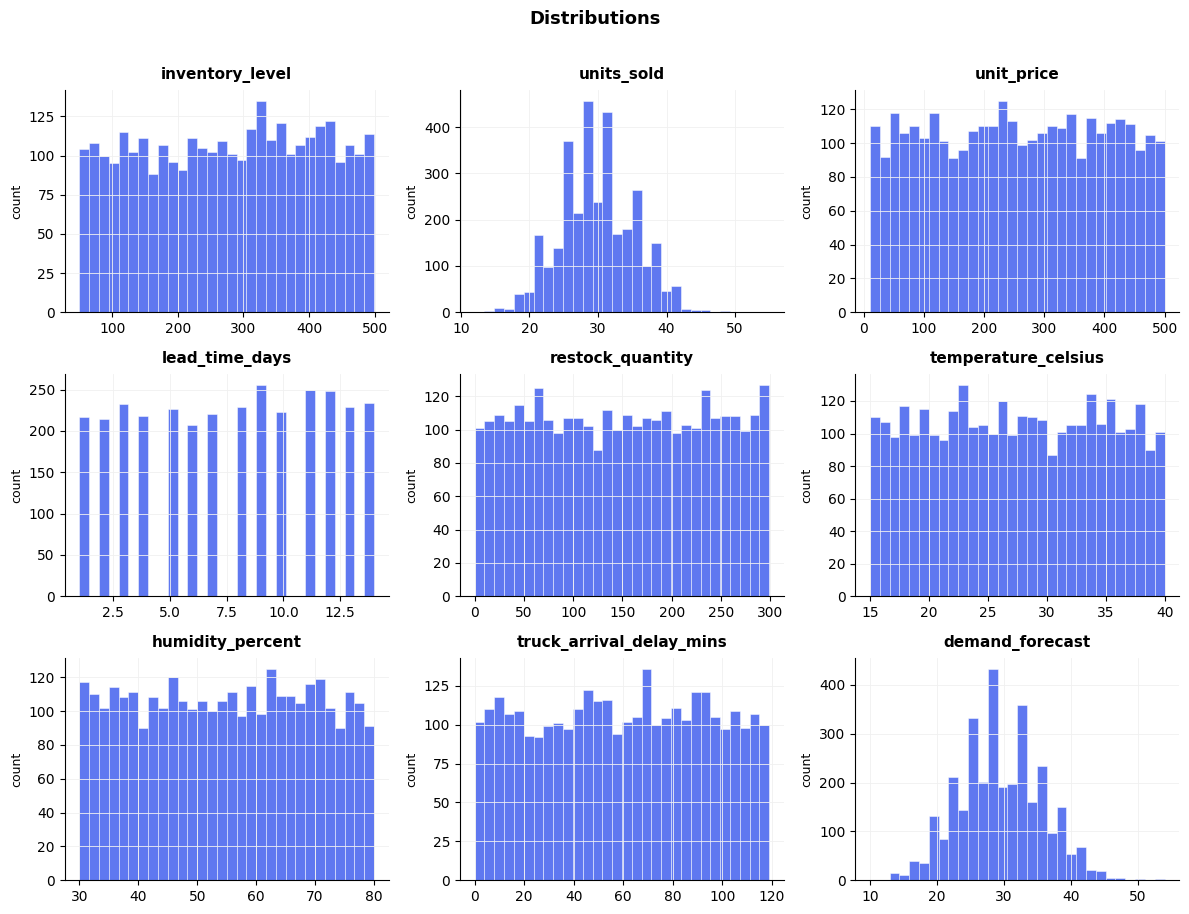

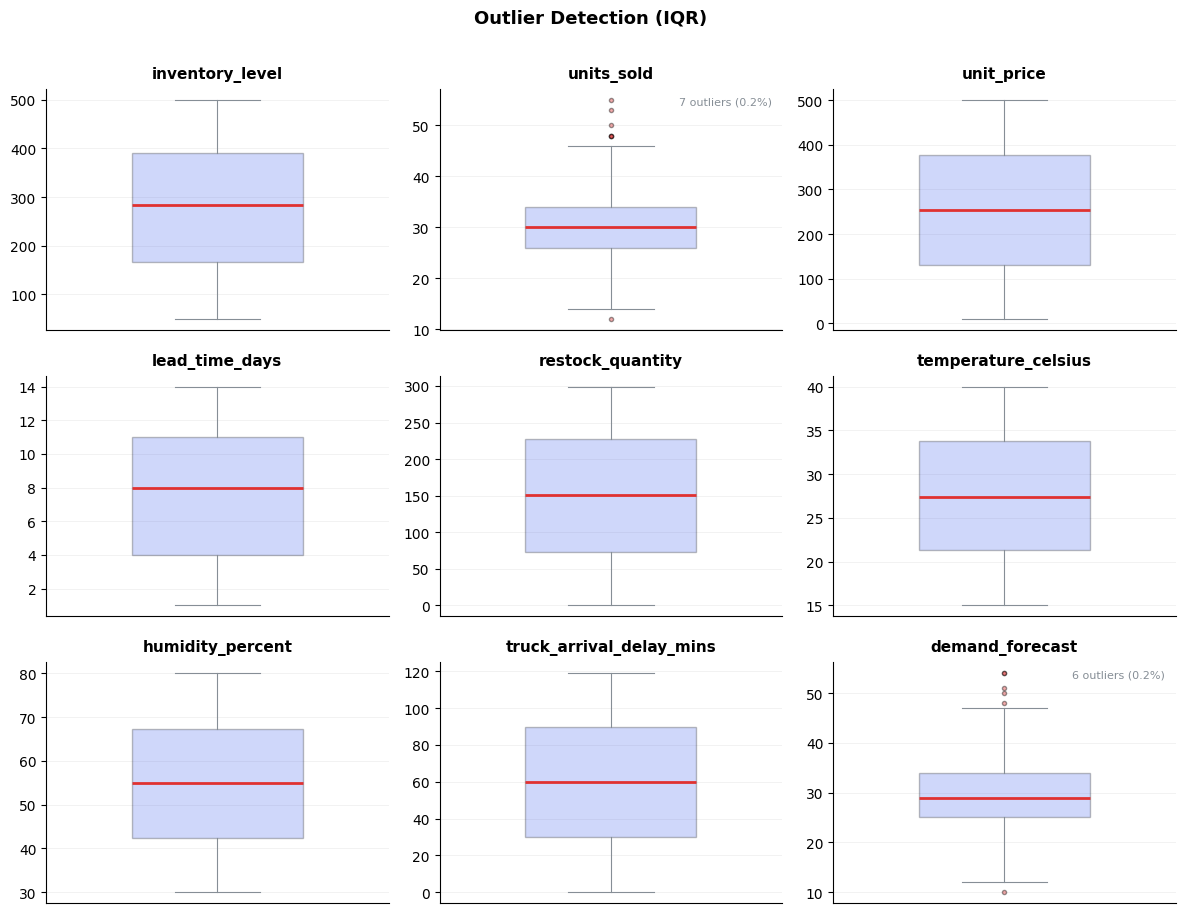

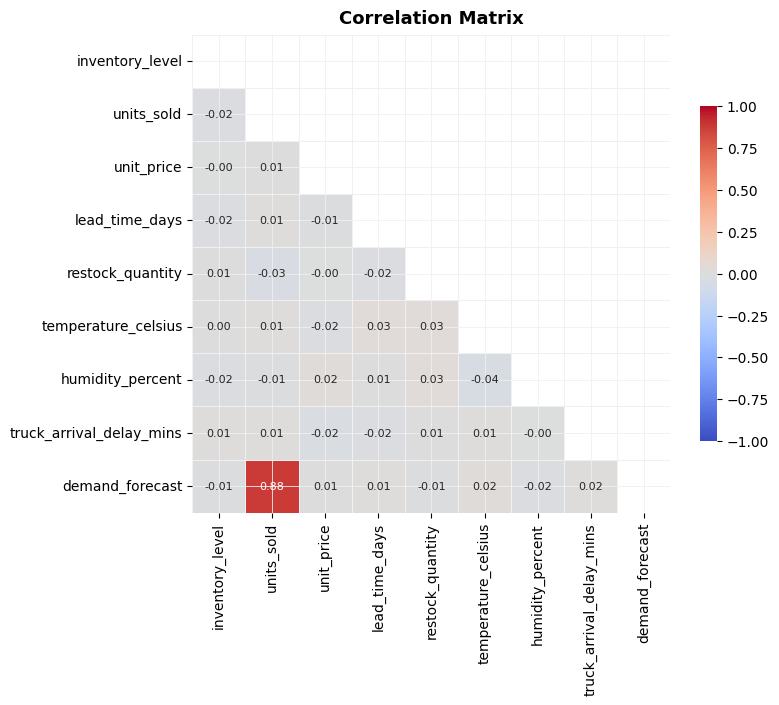

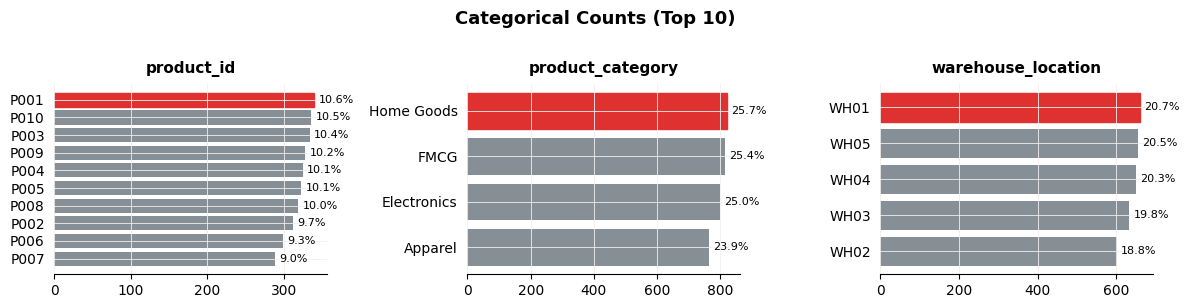

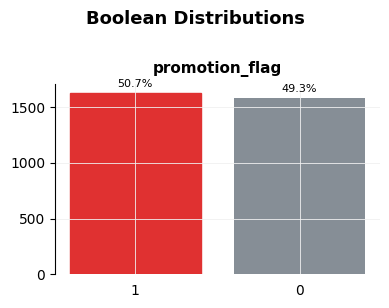

In [10]:
import pandas as pd
import quick_eda as qeda

# Use Case 1: The One-Liner (Default)
# -----------------------------------
# A standard run generates a robust, minimal-noise summary of your data:
#  - Overview: Row & column counts, missing %, duplicate count, size in MB.
#  - Warnings: Highlights ID-like columns, high-cardinality, skewness, & near-constant data.
#  - Suggestions: Actionable steps (e.g. "Drop user_id", "Impute missing income with median").
#  - Column Stats: Clear metrics for numeric, categorical, and datetime columns.
#  - Plots: Distribution histograms, Boxplots for outliers, and a target-aware Correlation heatmap.

df = pd.read_csv("datasets/Cloud_SupplyChain_Dataset.csv")
qeda.quick_eda(df)


  quick_eda
────────────────────────────────────────────────────
  rows               158
  columns             12
  missing           0.0%
  duplicates           0
  memory           0.03 MB
  numeric             10
  categorical          2
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  DROP
    Country                         Drop before modeling — appears to be a unique row identifier
    Happiness Rank                  Drop before modeling — appears to be a unique row identifier

  MODERATE
    Standard Error                  Apply log transform — right-skewed distribution (skew +1.98)
    Family                          Apply log transform — left-skewed distribution (skew -1.01)
    Health (Life Expectancy)        Mildly skewed (skew -0.71) — monitor, may not need transformation
    Trust (Government Corruption)   Apply log transform — right-skewed distribution (skew +1.39)
    Generosity                      Apply log transform

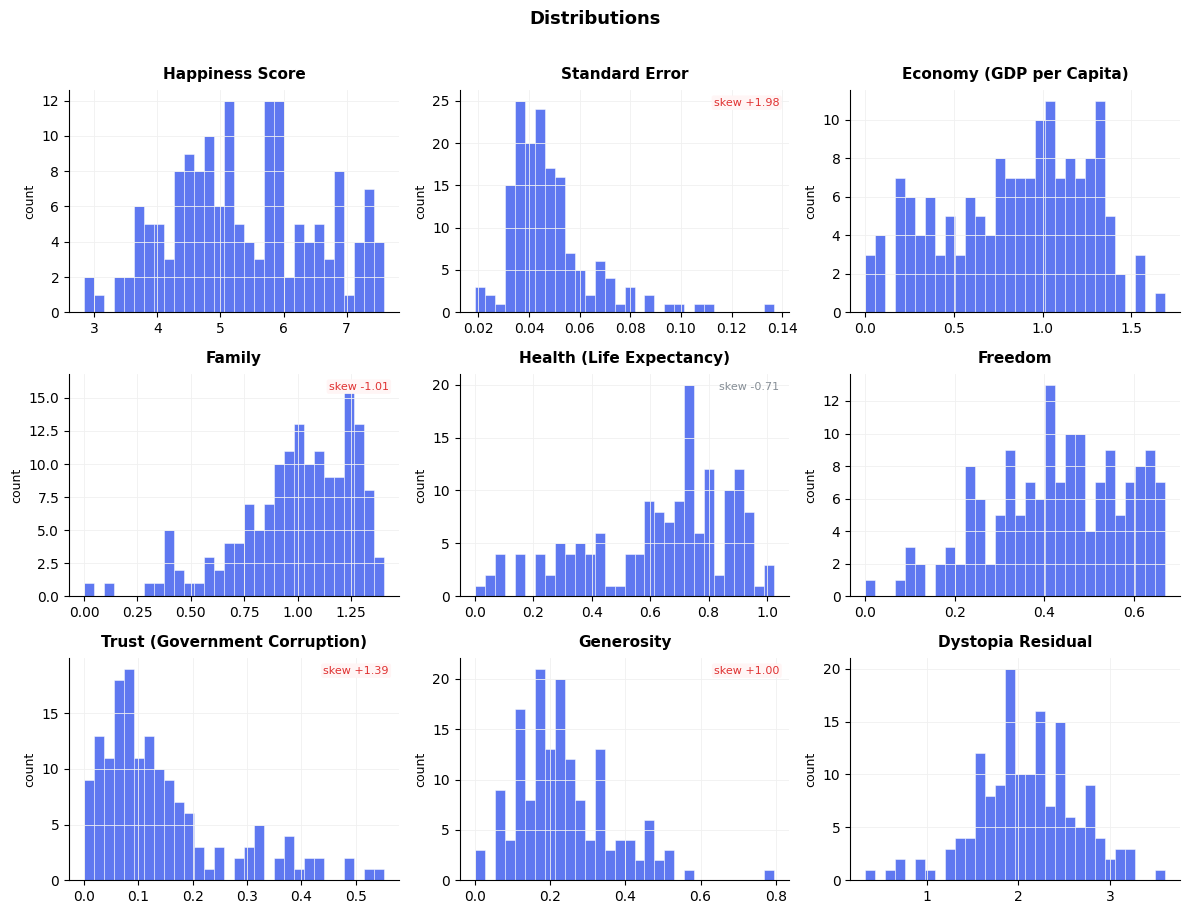

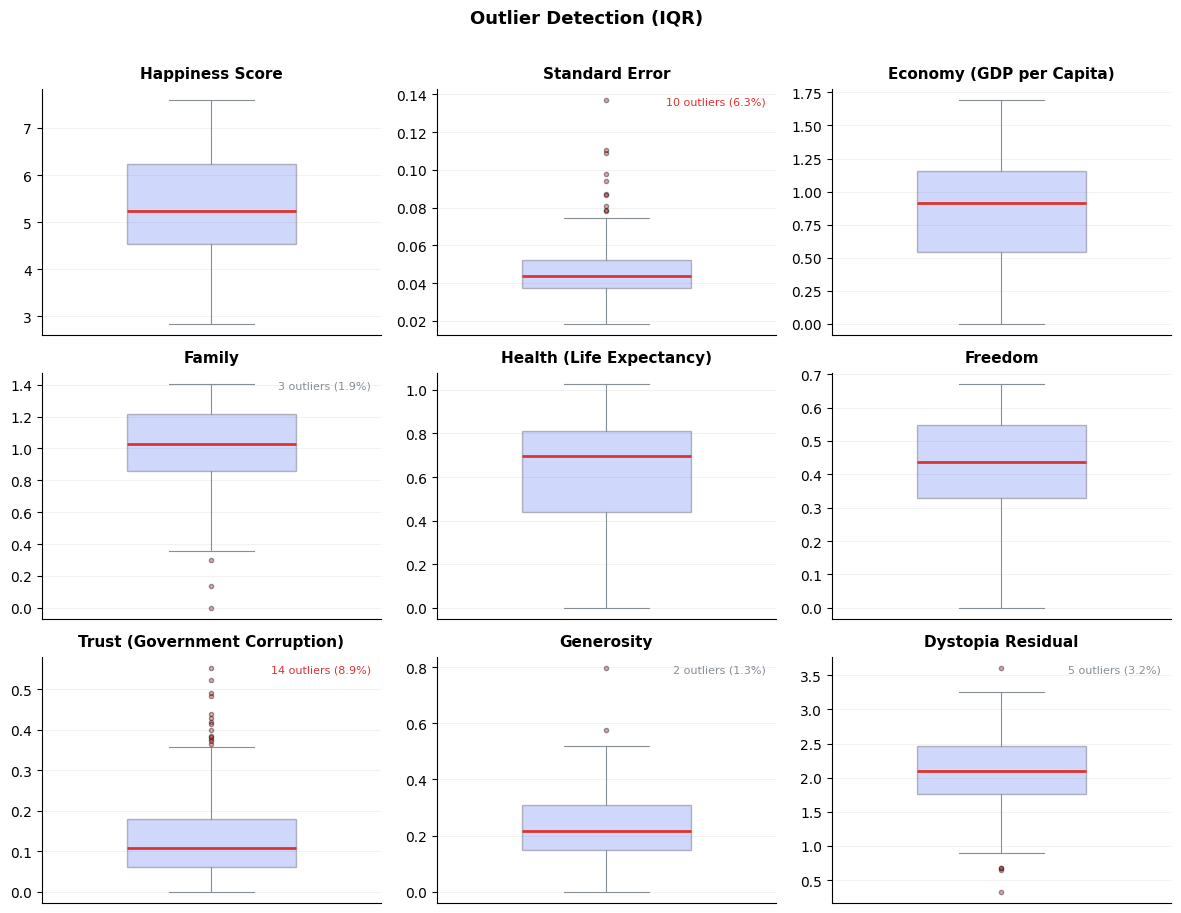

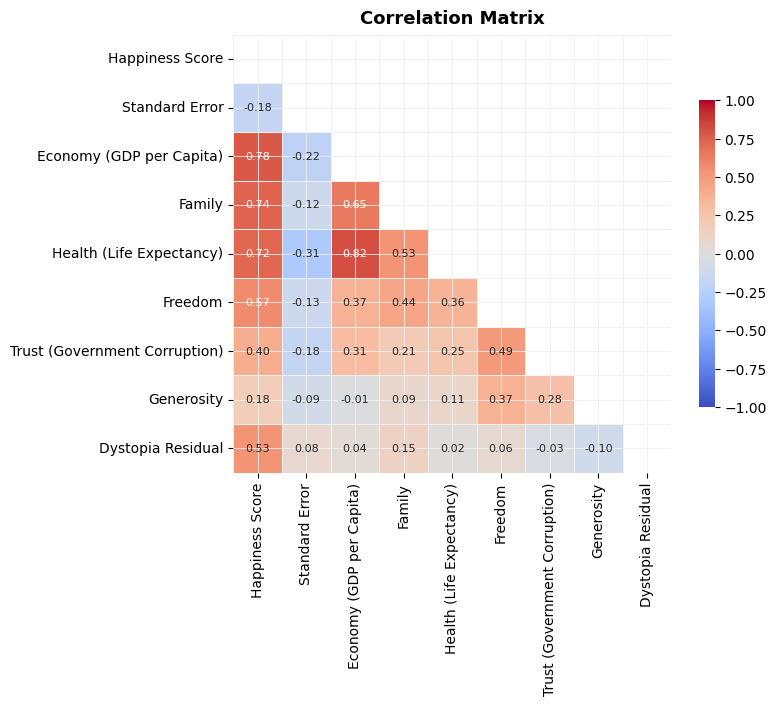

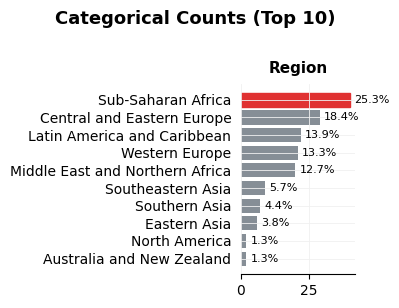

In [11]:
import pandas as pd
import quick_eda as qeda

# Use Case 2: Focus on a Target Column
# ------------------------------------
# By defining a target variable (`target="Happiness Score"`):
#  - Correlations are specifically ranked against your target column.
#  - Suggestions become model-aware (focusing on predictors for the target).
#  - Relationships to the target are emphasized in the text outputs.

df = pd.read_csv("datasets/2015.csv")
qeda.quick_eda(df, target="Happiness Score") # Adjust target name if different in CSV

In [12]:
import pandas as pd
import quick_eda as qeda

# Use Case 3: TL;DR Mode
# -----------------------
# Use `mode="tldr"` for text-only, instant results — skipping all plots and heavy processing.
# Ideal when you just need a swift summary of issues, warnings, and suggestions printed.

df = pd.read_csv("datasets/AB_NYC_2019.csv")
qeda.quick_eda(df, mode="tldr")


  quick_eda
────────────────────────────────────────────────────
  rows            48,895
  columns             16
  missing           2.6%
  duplicates           0
  memory          22.31 MB
  numeric             10
  categorical          6
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  DROP
    id                              Drop before modeling — appears to be a unique row identifier
    name                            Drop before modeling — appears to be a unique row identifier

  HIGH CONCERN
    last_review                     Impute with care — 20.6% missing, high enough to introduce bias
    reviews_per_month               Impute with care — 20.6% missing, high enough to introduce bias

  MODERATE
    host_id                         Apply log transform — right-skewed distribution (skew +1.21)
    host_name                       Many rare categories (100.0% of rows) — consider grouping into 'Other'
    neighbourhood          

In [13]:
import pandas as pd
import quick_eda as qeda

# Use Case 4: Skip Plots but Keep Full Stats
# ------------------------------------------
# Use `plots=False` to drop the visualizations (which take the longest to render) 
# while still retaining the detailed column stats, correlation rankings, and thorough text summary.
# Great for remote server runs or quick descriptive explorations.

df = pd.read_csv("datasets/amazon.csv")
qeda.quick_eda(df, plots=False)


  quick_eda
────────────────────────────────────────────────────
  rows             1,465
  columns             16
  missing           0.0%
  duplicates           0
  memory          10.87 MB
  numeric              0
  categorical         16
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  DROP
    img_link                        Drop before modeling — appears to be a unique row identifier
    product_link                    Drop before modeling — appears to be a unique row identifier

  MODERATE
    product_id                      Many rare categories (100.0% of rows) — consider grouping into 'Other'
    product_name                    Many rare categories (100.0% of rows) — consider grouping into 'Other'
    category                        Many rare categories (45.6% of rows) — consider grouping into 'Other'
    discounted_price                Many rare categories (68.6% of rows) — consider grouping into 'Other'
    actual_price     


  quick_eda
────────────────────────────────────────────────────
  rows            15,411
  columns             14
  missing           0.0%
  duplicates           0
  memory           6.20 MB
  numeric              8
  categorical          6
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  DROP
    Unnamed: 0                      Drop before modeling — appears to be a unique row identifier

  MODERATE
    car_name                        Many rare categories (20.3% of rows) — consider grouping into 'Other'
    brand                           High cardinality (32 unique values) — consider grouping rare categories or target encoding
    model                           Many rare categories (20.3% of rows) — consider grouping into 'Other'
    vehicle_age                     Mildly skewed (skew +0.83) — monitor, may not need transformation
    km_driven                       Apply log transform — right-skewed distribution (skew +28.17)
    e

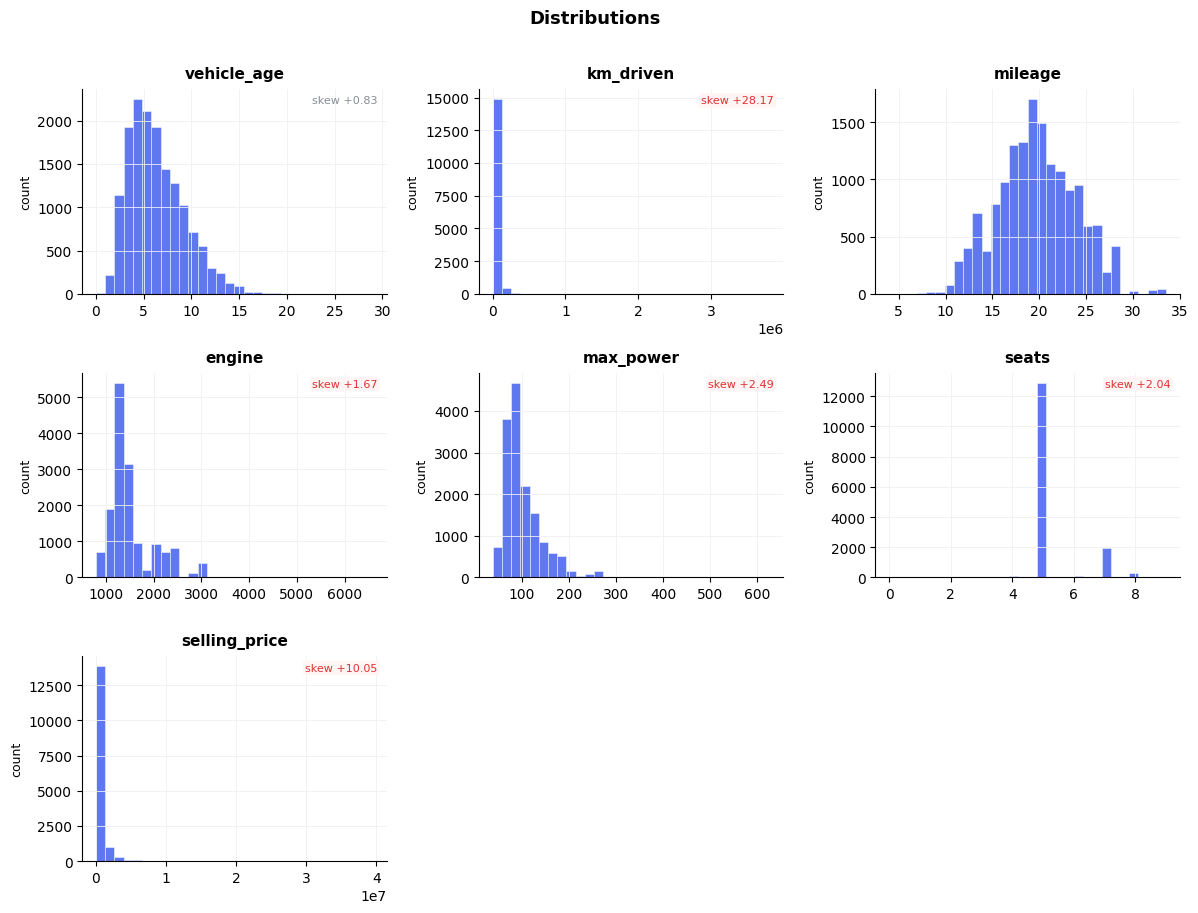

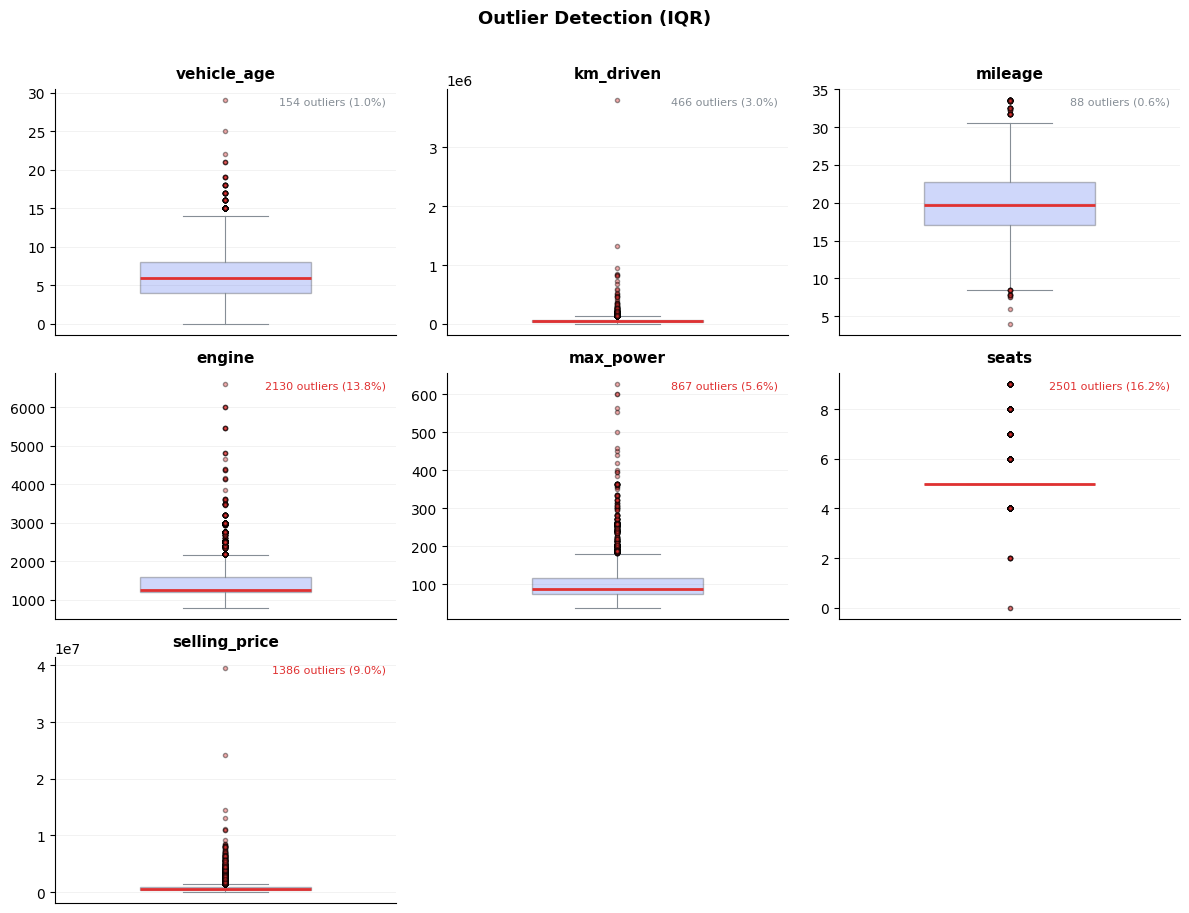

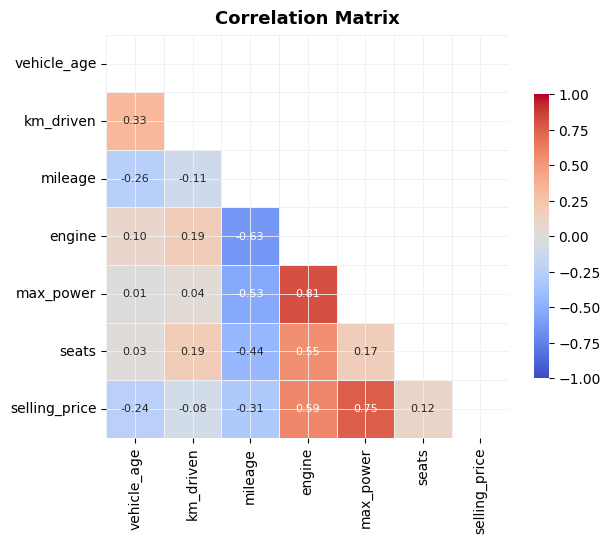

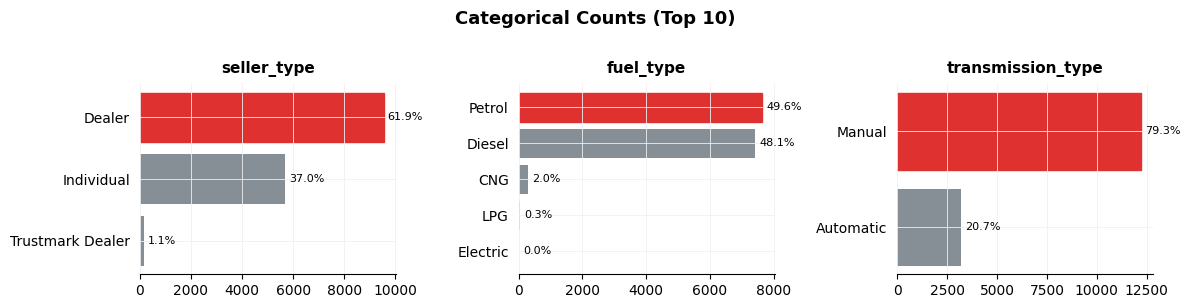


--- Programmatic Suggestions ---
{'Unnamed: 0': ['Drop before modeling — appears to be a unique row identifier'], 'car_name': ["Many rare categories (20.3% of rows) — consider grouping into 'Other'"], 'brand': ['High cardinality (32 unique values) — consider grouping rare categories or target encoding'], 'model': ["Many rare categories (20.3% of rows) — consider grouping into 'Other'"], 'vehicle_age': ['Mildly skewed (skew +0.83) — monitor, may not need transformation'], 'km_driven': ['Apply log transform — right-skewed distribution (skew +28.17)', 'Heavy-tailed distribution (kurtosis 1846.53) — extreme values may affect model'], 'engine': ['Apply log transform — right-skewed distribution (skew +1.67)', 'Investigate outliers — 13.8% of values fall outside IQR bounds', 'Heavy-tailed distribution (kurtosis 4.33) — extreme values may affect model'], 'max_power': ['Apply log transform — right-skewed distribution (skew +2.49)', 'Some outliers present — 5.6% beyond IQR bounds, review before

In [14]:
import pandas as pd
import quick_eda as qeda

# Use Case 5: Programmatic Report Retrieval
# -----------------------------------------
# Set `return_report=True` to get a structured dictionary back alongside the standard output.
# You can use the returned report programmatically in automated pipelines (e.g., to fetch missing
# column lists, suggestions, or correlation dictionaries without manual review).

df = pd.read_csv("datasets/cardekho_dataset.csv")
report = qeda.quick_eda(df, return_report=True)

# e.g., using it downstream
if report and "suggestions" in report:
    print("\n--- Programmatic Suggestions ---")
    print(report["suggestions"])


  quick_eda
────────────────────────────────────────────────────
  rows            15,411
  columns             14
  missing           0.0%
  duplicates           0
  memory           6.20 MB
  numeric              8
  categorical          6
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  DROP
    Unnamed: 0                      Drop before modeling — appears to be a unique row identifier

  MODERATE
    car_name                        Many rare categories (20.3% of rows) — consider grouping into 'Other'
    brand                           High cardinality (32 unique values) — consider grouping rare categories or target encoding
    model                           Many rare categories (20.3% of rows) — consider grouping into 'Other'
    vehicle_age                     Mildly skewed (skew +0.83) — monitor, may not need transformation
    km_driven                       Apply log transform — right-skewed distribution (skew +28.17)
    e

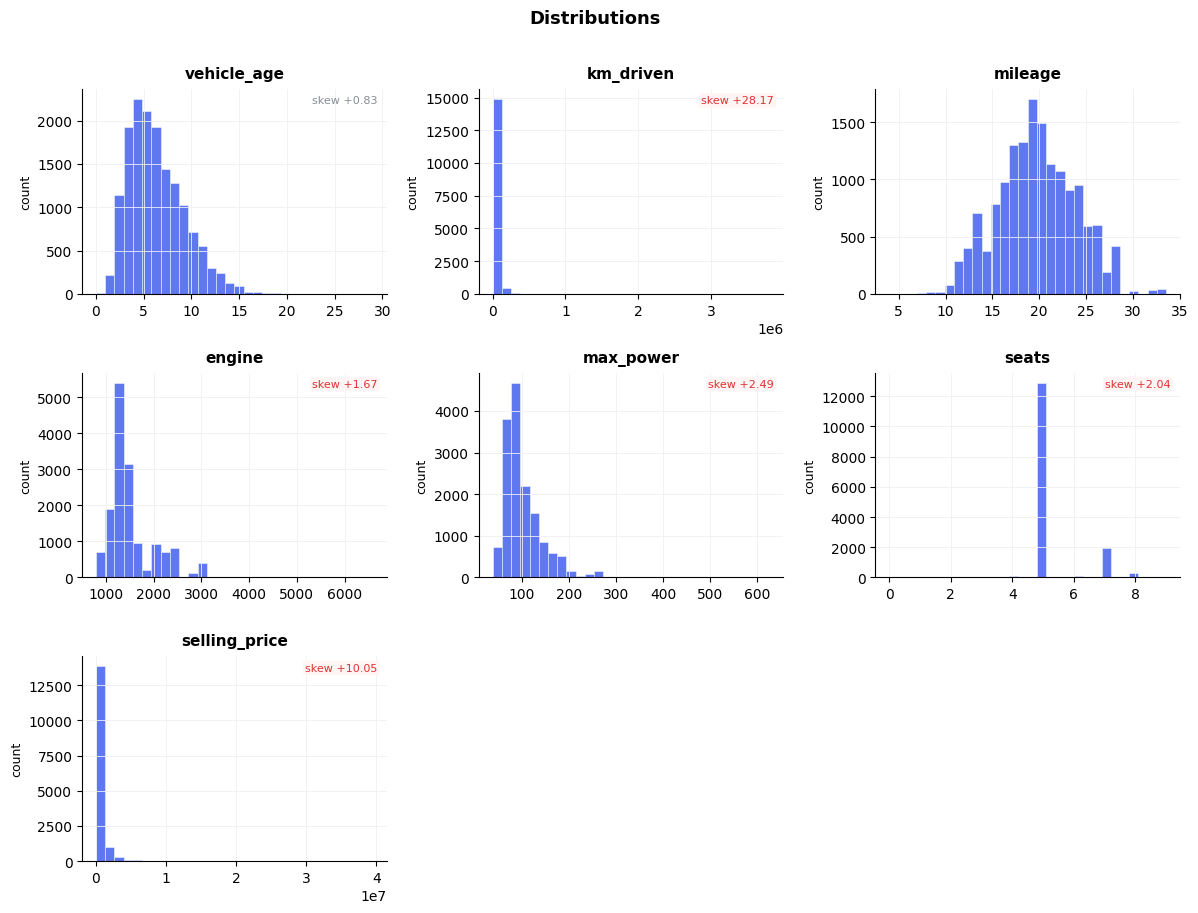

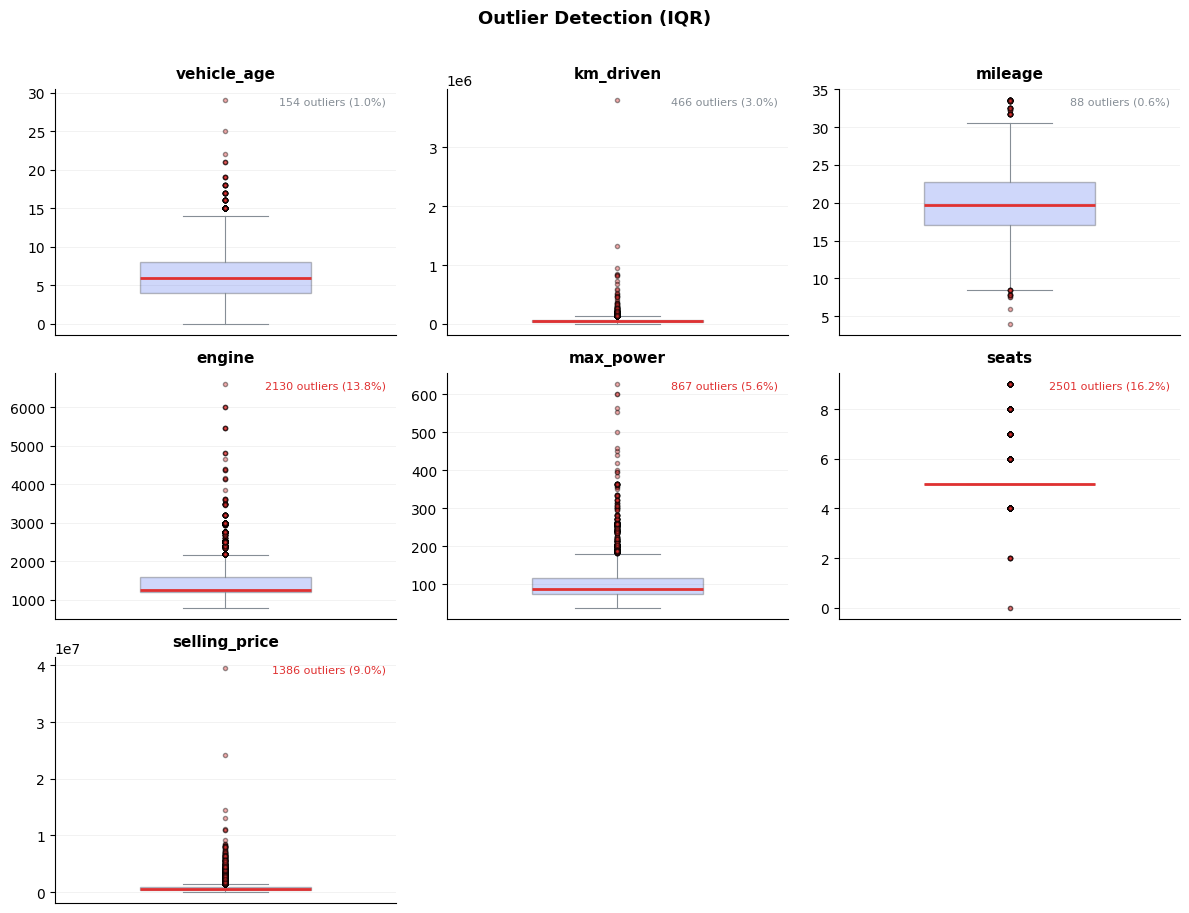

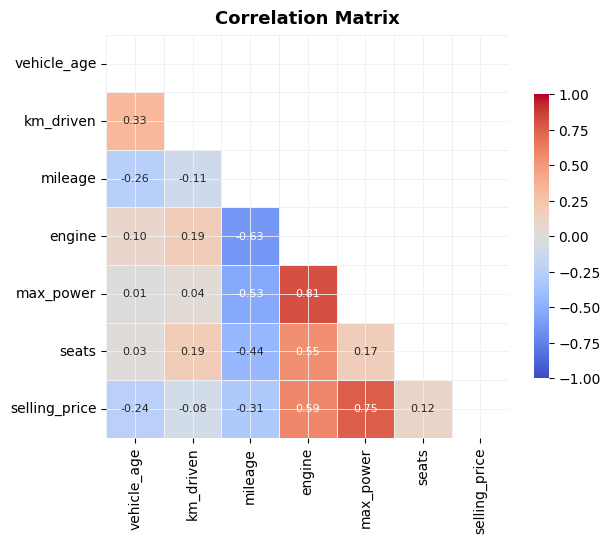

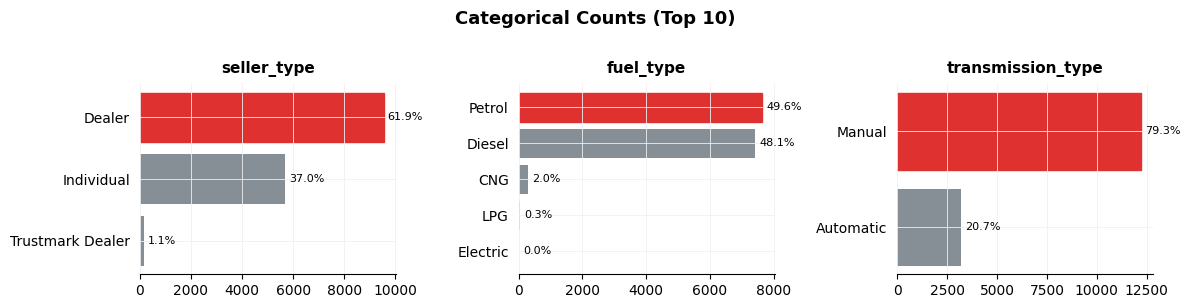

In [15]:
import pandas as pd
import quick_eda as qeda

# Use Case 6: Large Dataset Handling
# ----------------------------------
# By default, quick_eda auto-samples to 50k rows if df is extremely large.
# This keeps the EDA results fast and memory footprints clean, enabling 
# preliminary analysis even for hefty datasets without crashing the notebook kernel.

df = pd.read_csv("datasets/cardekho_dataset.csv")
qeda.quick_eda(df)

⚡ Large dataset detected (86,512 rows) — running on 50,000 row sample. Pass sample=False to use full data.

  quick_eda
────────────────────────────────────────────────────
  rows            50,000
  columns             15
  missing          24.9%  !
  duplicates           0
  memory          25.96 MB
  numeric              9
  categorical          6
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───

  HIGH CONCERN
    total_vaccinations              Impute with care — 49.6% missing, high enough to introduce bias
    people_vaccinated               Consider dropping — 52.3% of values are missing
    people_fully_vaccinated         Consider dropping — 55.2% of values are missing
    daily_vaccinations_raw          Consider dropping — 59.1% of values are missing
    total_vaccinations_per_hundred  Impute with care — 49.6% missing, high enough to introduce bias
    people_vaccinated_per_hundred   Consider dropping — 52.3% of values are missing

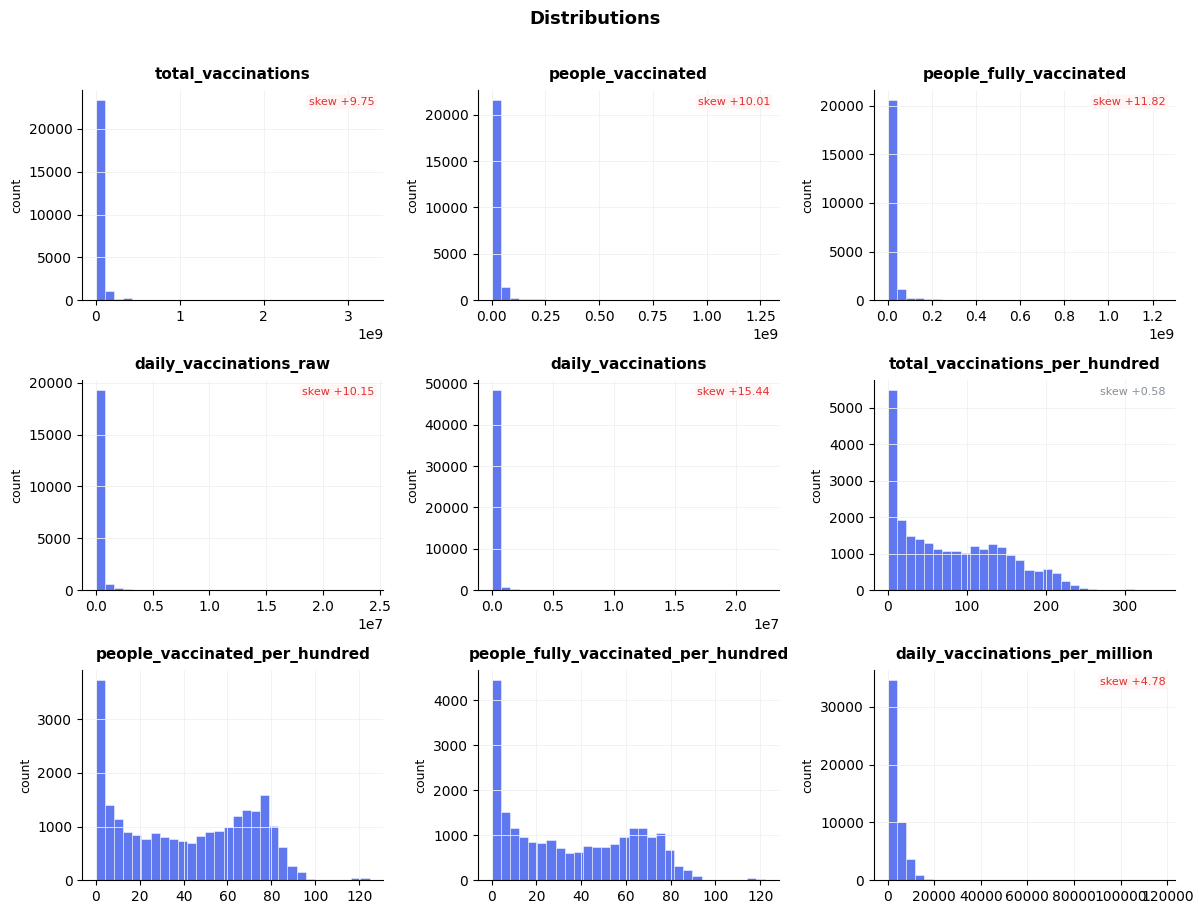

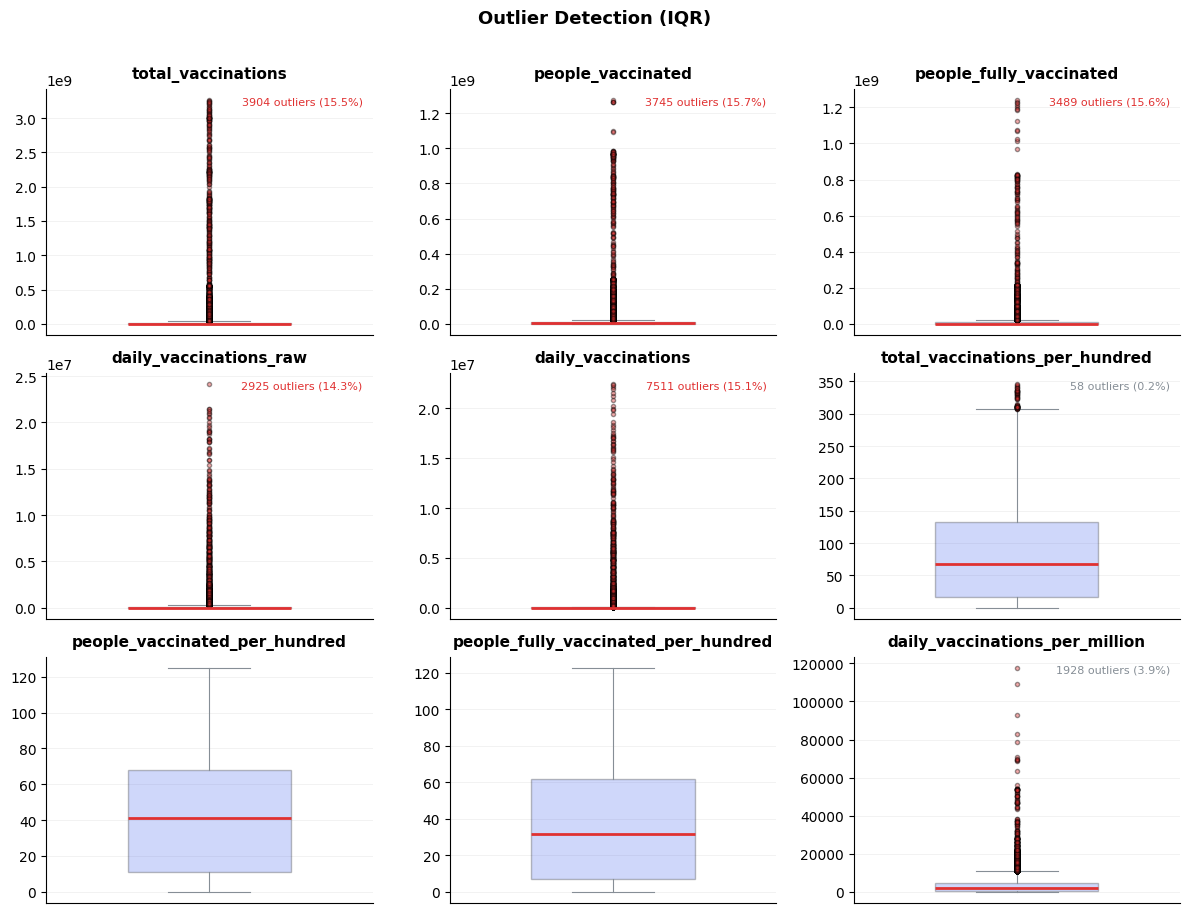

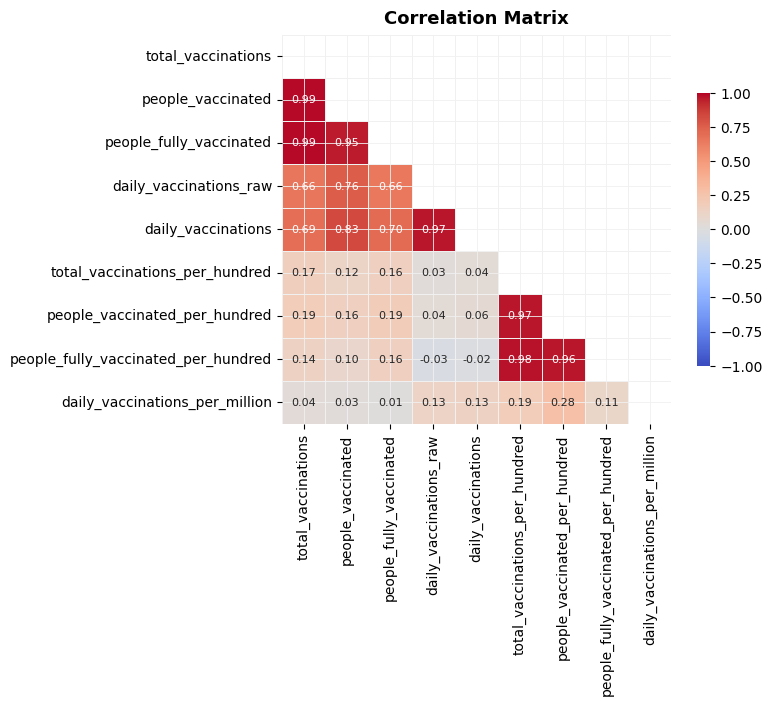

In [16]:
import pandas as pd
import quick_eda as qeda

# Use Case 7: Missing Value & Datetime Auto-detection
# ---------------------------------------------------
# The internal Profiler efficiently detects:
#  - Datetime data stored inside generic object/string types.
#  - Percentage of missing completely at random (MCAR) data.
# It then specifically offers automated Imputation Strategy suggestions
# (e.g. median/mode imputes suitable for your distribution missingness).

df = pd.read_csv("datasets/country_vaccinations.csv")
qeda.quick_eda(df)

In [17]:
import pandas as pd
import quick_eda as qeda

# Use Case 8: Targeting Class Imbalance
# -------------------------------------
# Works well to detect highly imbalanced generic classification targets like Fraud.
# The Warning output explicitly highlights low-variance / near-constant values.
# Applying a target parameter subsequently narrows your focus toward feature 
# relationships relative to that minor/imbalanced class column.

df = pd.read_csv("datasets/credit_card_fraud_dataset.csv")
qeda.quick_eda(df, target="Class")

ValueError: Target column 'Class' not found in DataFrame. Available columns: ['TransactionID', 'TransactionDate', 'Amount', 'MerchantID', 'TransactionType', 'Location', 'IsFraud']

In [ ]:
!pip install xlrd openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [openpyxl]2/3 [openpyxl]



  quick_eda
────────────────────────────────────────────────────
  rows             1,338
  columns              7
  missing           0.0%
  duplicates           1  !
  memory           0.26 MB
  numeric              4
  categorical          3
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───
  WARNINGS

  MODERATE
    children                        Mildly skewed (skew +0.94) — monitor, may not need transformation
    charges                         Apply log transform — right-skewed distribution (skew +1.52)

─── SUGGESTIONS ───
  SUGGESTIONS

   1.  Remove 1 duplicate rows
   2.  [children]  Mildly skewed (skew +0.94) — monitor, may not need transformation
   3.  [charges]  Apply log transform — right-skewed distribution (skew +1.52)
   4.  [charges]  Investigate outliers — 10.4% of values fall outside IQR bounds

─── COLUMN STATS ───

  COLUMN STATS

          count  missing %        mean    median         std        min        max   

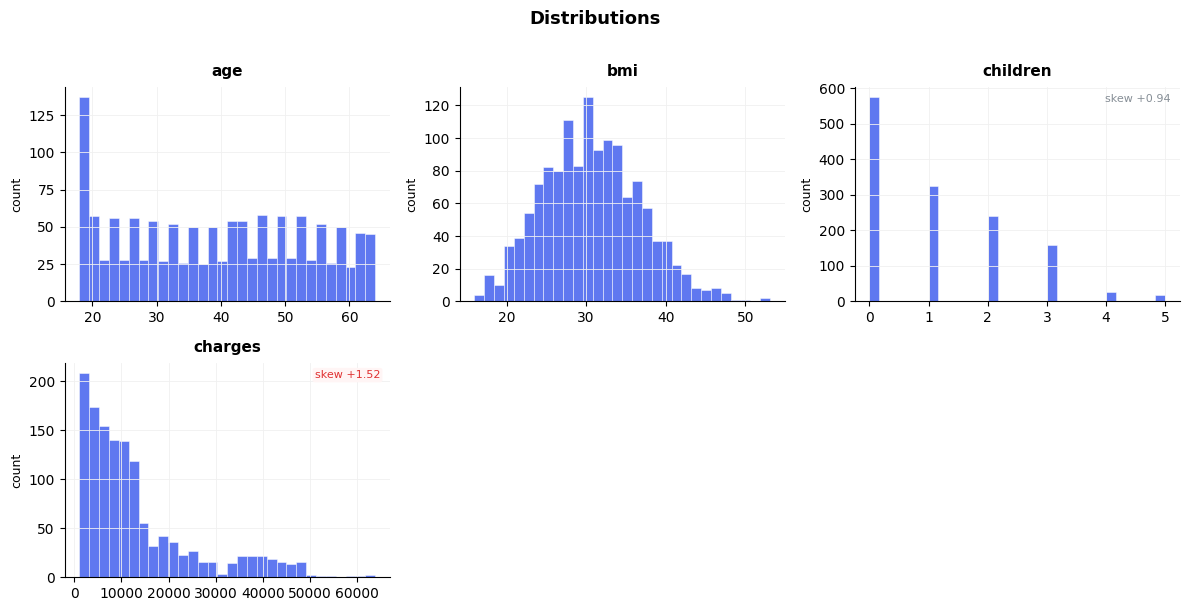

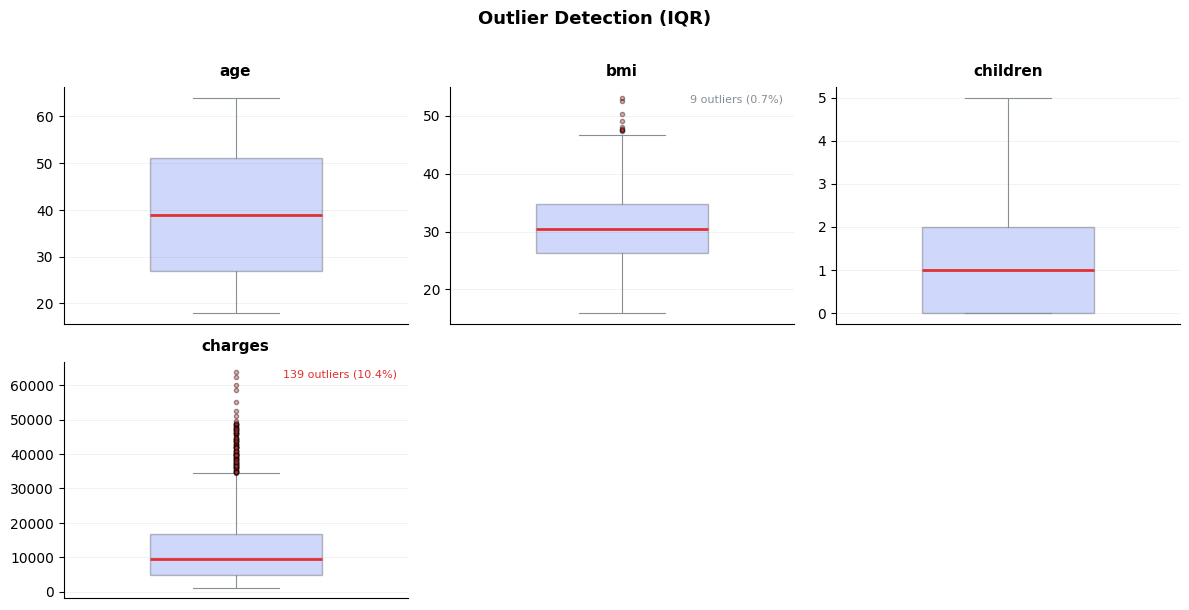

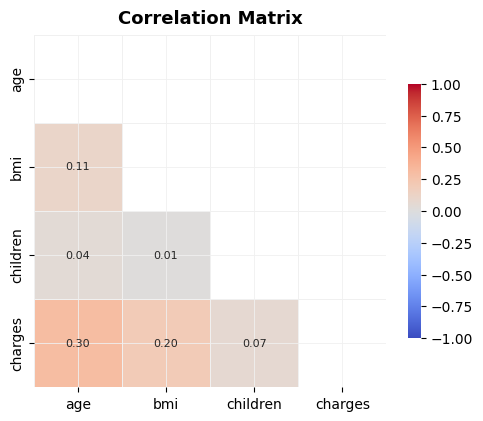

In [ ]:
import pandas as pd
import quick_eda as qeda

# Use Case 11: Loading Excel (.xls) Data
# --------------------------------------
# quick_eda works just as flexibly with alternative formats like .xls extensions.
# Ensure `xlrd` or `openpyxl` is installed. 
# (Note: pd.read_csv or read_excel can be used based on the exact format of your file.)

df = pd.read_csv("datasets/insurance.xls")
qeda.quick_eda(df)


  quick_eda
────────────────────────────────────────────────────
  rows             2,240
  columns             29
  missing           0.0%
  duplicates           0
  memory           0.85 MB
  numeric             26
  categorical          3
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───
  WARNINGS

  DROP
    ID                              Drop before modeling — appears to be a unique row identifier
    AcceptedCmp2                    Consider dropping — near-constant, one value dominates 100% of rows
    Complain                        Consider dropping — near-constant, one value dominates 100% of rows
    Z_CostContact                   Drop — constant column, carries no information
    Z_Revenue                       Drop — constant column, carries no information

  MODERATE
    Income                          Impute with median — 1.1% missing
    Kidhome                         Mildly skewed (skew +0.64) — monitor, may not need tr

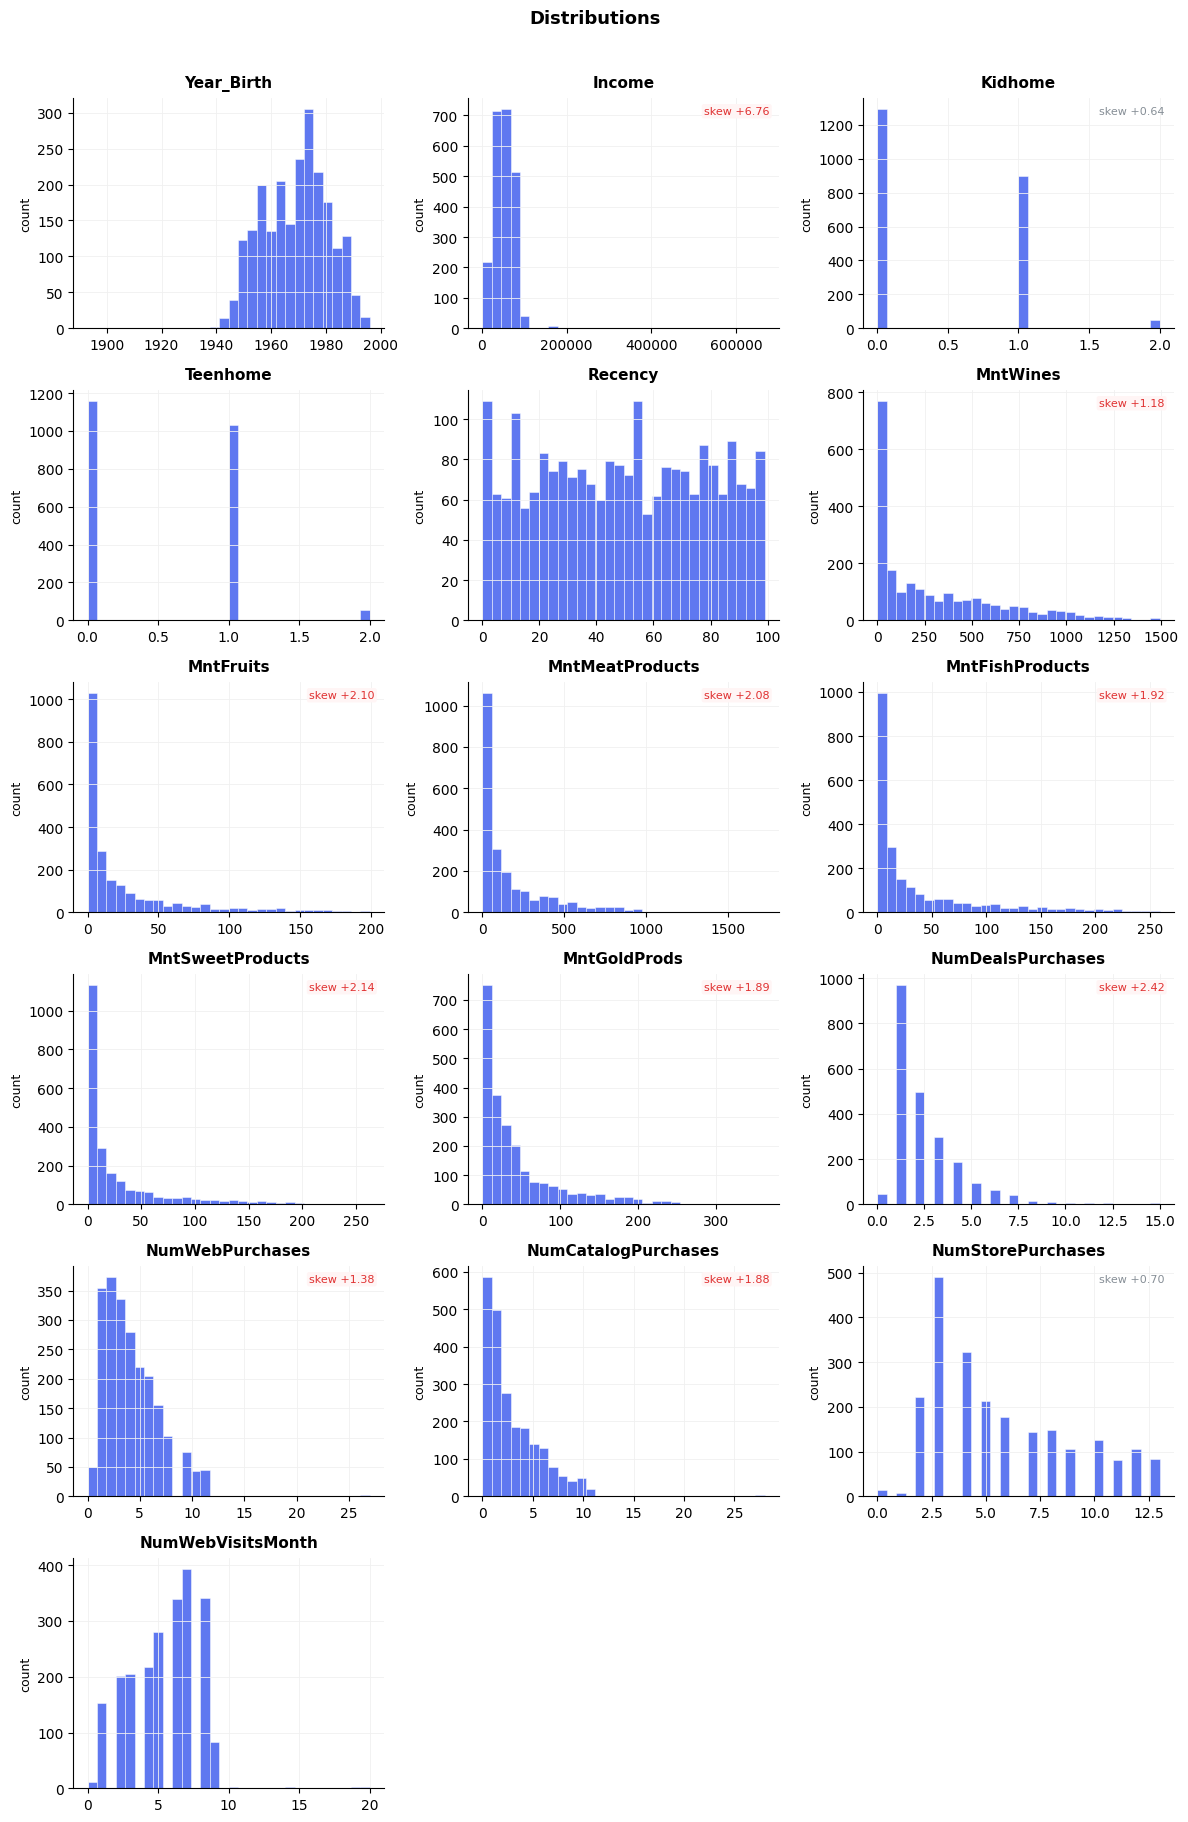

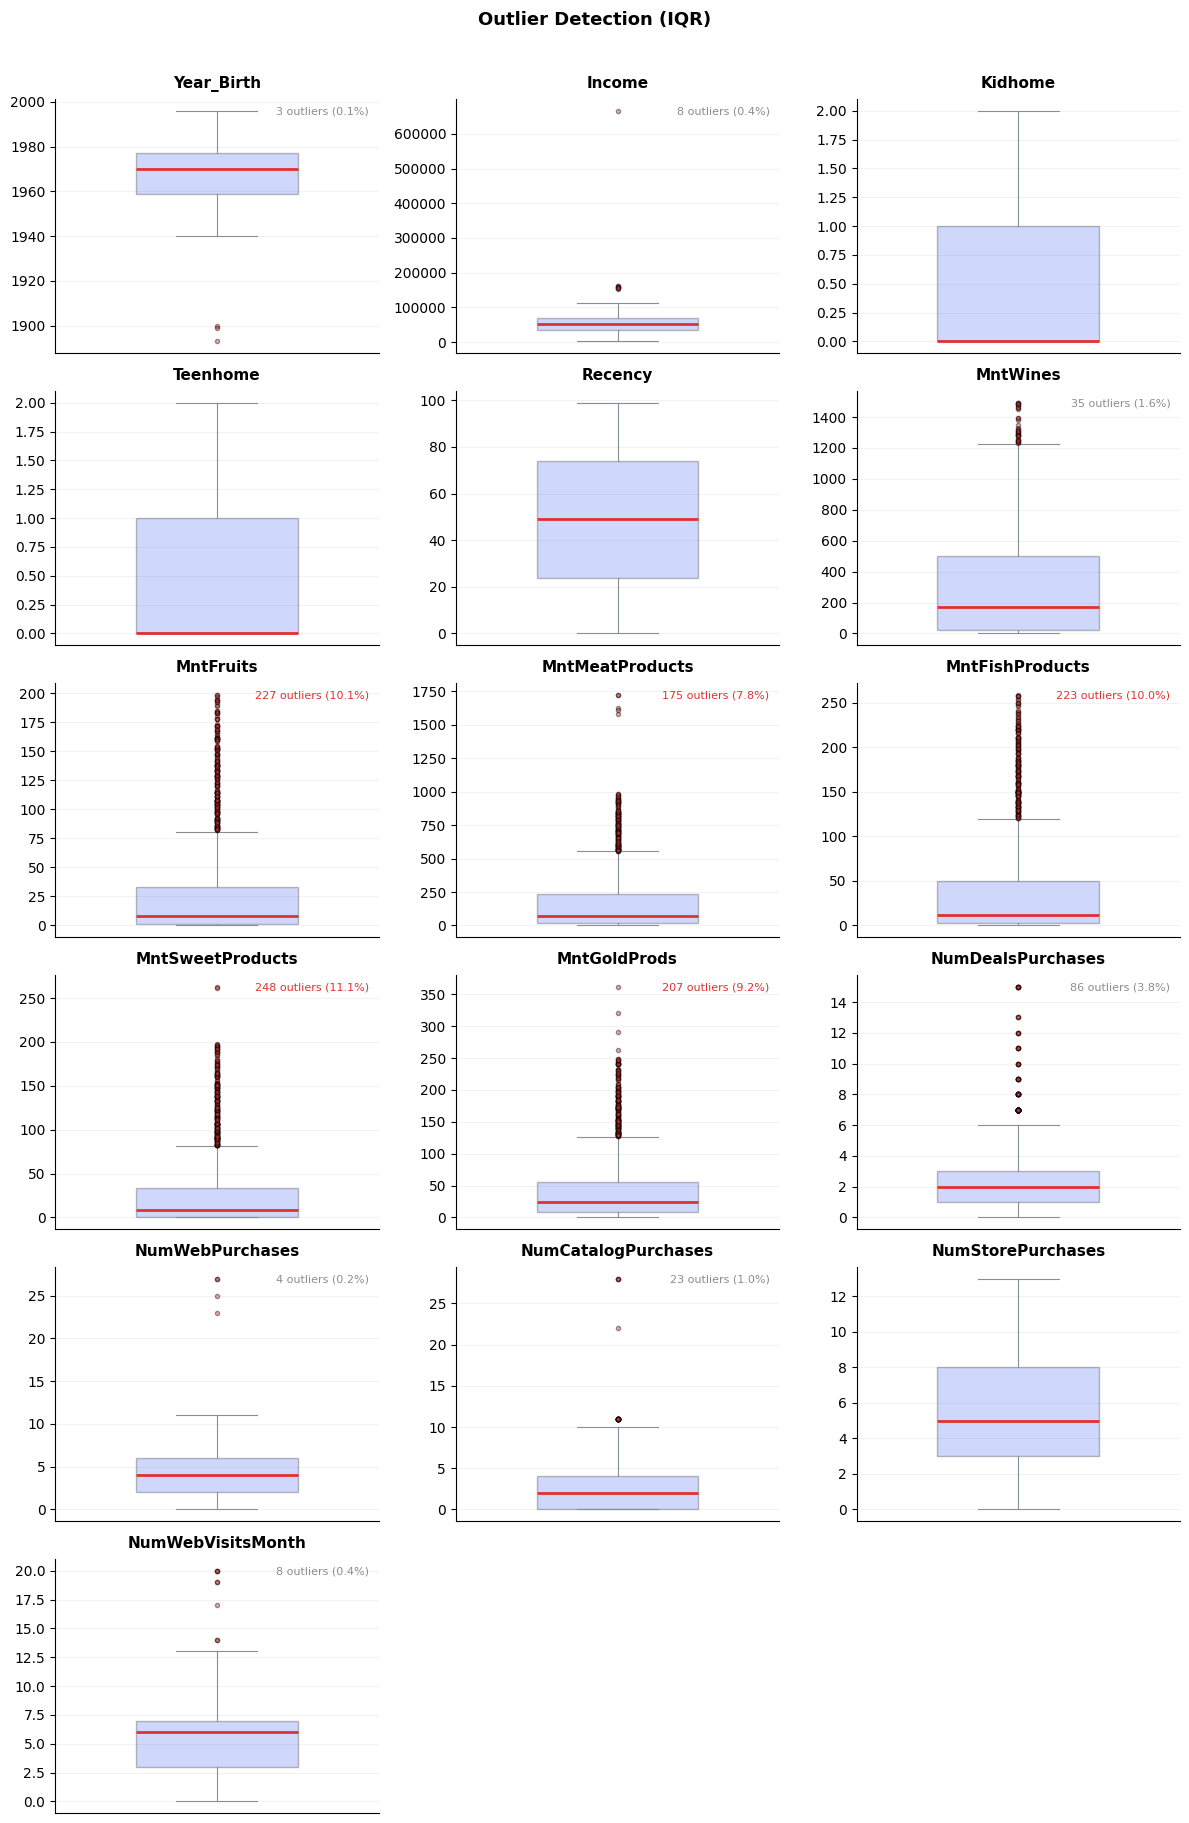

In [ ]:
import pandas as pd
import quick_eda as qeda

# Use Case 12: Tab-Separated Data (.xls / .tsv)
# ---------------------------------------------
# You might encounter `.xls` files that are simply tab-separated values underneath.
# Use standard pandas kwargs like `sep="\t"` and let quick_eda do the heavy lifting.

df = pd.read_csv("datasets/marketing_campaign.xls", sep="\t")
qeda.quick_eda(df)


  quick_eda
────────────────────────────────────────────────────
  rows             8,807
  columns             12
  missing           4.1%
  duplicates           0
  memory           8.37 MB
  numeric              1
  categorical         11
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───
  WARNINGS

  DROP
    show_id                         Drop before modeling — appears to be a unique row identifier
    title                           Drop before modeling — appears to be a unique row identifier
    description                     Drop before modeling — appears to be a unique row identifier

  HIGH CONCERN
    director                        Impute with care — 29.9% missing, high enough to introduce bias

  MODERATE
    cast                            Impute with mode — 9.4% missing
    country                         Impute with mode — 9.4% missing
    release_year                    Apply log transform — left-skewed distribution (ske

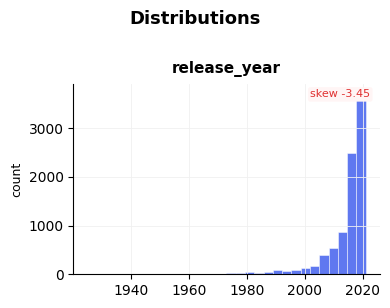

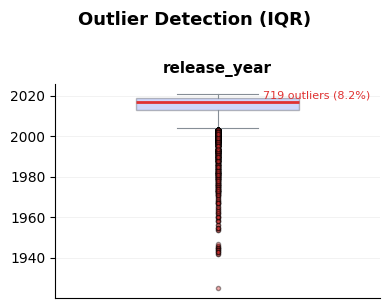

In [ ]:
import pandas as pd
import quick_eda as qeda

# Use Case 9: Text Heavy / Categorical Datasets
# ---------------------------------------------
# For descriptive string datasets (e.g., NLP features, reviews, media titles),
# quick_eda excels at identifying high-cardinality nominals. 
# It advises against utilizing strictly unstructured text columns without NLP preprocessing
# or extracting categorical clusters instead of leaving them as-is.

df = pd.read_csv("datasets/netflix_titles.csv")
qeda.quick_eda(df)


  quick_eda
────────────────────────────────────────────────────
  rows             7,105
  columns             12
  missing           0.1%
  duplicates           0
  memory           3.31 MB
  numeric              5
  categorical          7
  datetime             0
────────────────────────────────────────────────────

─── WARNINGS ───
  WARNINGS

  DROP
    Unnamed: 0.1                    Identical values to 'Unnamed: 0' — drop one before modeling
    Unnamed: 0                      Drop before modeling — appears to be a unique row identifier
    restaurant name                 Drop before modeling — appears to be a unique row identifier

  MODERATE
    restaurant type                 High cardinality (81 unique values) — consider grouping rare categories or target encoding
    rate (out of 5)                 Impute with median — 1.0% missing
    num of ratings                  Apply log transform — right-skewed distribution (skew +10.93)
    avg cost (two people)           Impute wi

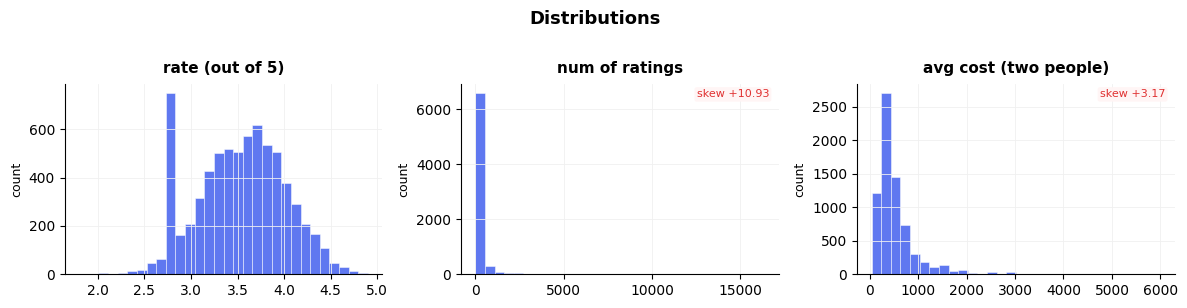

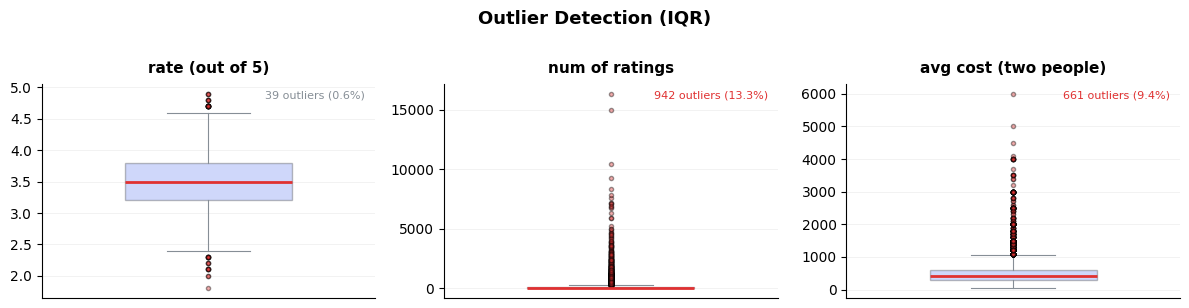

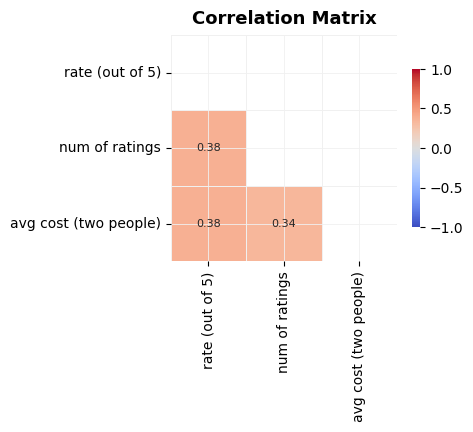

In [ ]:
import pandas as pd
import quick_eda as qeda

# Use Case 10: Messy Real-World Data
# ----------------------------------
# Designed to be robust against highly uncleaned data.
# For examples datasets like Zomato which contain massive variation in scoring, 
# unstructured text strings, and messy cost representations requiring heavy sanitization.

df = pd.read_csv("datasets/zomato.csv")
qeda.quick_eda(df)